# Data analisys

Before developing regression models, analysing our data may reveal important information. With the acquired knowledge, we may be able to detect problems and quirks in our data, and deal with them properly.

## Setup

### Library loading

In [1]:
import locale
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer

locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')

'en_US.UTF-8'

### Data loading

In [2]:
df = pd.read_parquet("data/datasets")

### Constants

In [3]:
REF_YEAR = 2000  # leap year — safely handles doy 366 if present

## Basic structure

Let's validate the dataset before any advanced analysis.

### Shape

In [4]:
df.shape

(26482762, 52)

We can see we have a very substantial amount of data.

### Variables

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26482762 entries, 0 to 26482761
Data columns (total 52 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   latitude_grid                float32
 1   longitude_grid               float32
 2   surtep_ERA5                  float32
 3   fwns                         float32
 4   Tmn                          float32
 5   PWV                          float32
 6   VOD                          float32
 7   vsm                          float32
 8   VPD                          float32
 9   quality_flag                 float32
 10  ref_land_emis_de_lannoy_K_h  float32
 11  ref_land_emis_de_lannoy_K_v  float32
 12  tbtoa19V                     float32
 13  tbtoa19H                     float32
 14  tbtoa37V                     float32
 15  tbtoa37H                     float32
 16  tran19V                      float32
 17  tran19H                      float32
 18  tran37V                      float32
 19

All variables are float32, which means the standarization process was successfull.

### Simple statistics

In [6]:
df.describe(include="all")

,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,quality_flag,...,term_2,fwns_calculated,clase,porcentaje clase,day_of_year,year,doy_sin,doy_cos,lon_sin,lon_cos
count,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,...,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07
mean,3.590511e+01,1.391595e+02,2.858685e+02,3.500325e-02,2.826018e+02,1.935768e+01,4.021553e-01,1.874782e-01,5.912334e-01,5.392265e+00,...,1.425153e+00,4.469923e-02,9.213342e+00,1.611363e+01,1.988049e+02,2.017515e+03,-1.736883e-01,-3.103183e-01,2.237418e-01,1.378912e-01
std,2.999292e+01,1.018479e+02,3.948494e+01,5.499873e-02,4.247716e+01,1.052966e+01,1.839654e-01,8.932661e-02,7.241248e-01,2.348640e+01,...,1.776583e-01,8.470134e-02,1.129744e+01,2.070355e+01,8.445500e+01,5.763195e+02,6.633229e-01,6.271846e-01,7.092074e-01,6.008372e-01
min,-5.562500e+01,1.250000e-01,2.396749e+02,0.000000e+00,2.588824e+02,0.000000e+00,0.000000e+00,2.500000e-02,0.000000e+00,0.000000e+00,...,5.653071e-01,-7.023463e-01,0.000000e+00,0.000000e+00,1.000000e+00,2.017000e+03,-9.999908e-01,-9.999630e-01,-9.999976e-01,-9.999976e-01
25%,1.837500e+01,5.187500e+01,2.794391e+02,0.000000e+00,2.753934e+02,1.198728e+01,2.677364e-01,1.228009e-01,3.285241e-02,0.000000e+00,...,1.396227e+00,-6.397945e-03,0.000000e+00,0.000000e+00,1.490000e+02,2.017000e+03,-8.359255e-01,-8.977434e-01,-6.739802e-01,-4.087287e-01
50%,4.687500e+01,1.118750e+02,2.862344e+02,1.186447e-02,2.814135e+02,1.732748e+01,4.013865e-01,2.016385e-01,2.874887e-01,0.000000e+00,...,1.437030e+00,1.883566e-02,0.000000e+00,6.000000e+00,2.040000e+02,2.018000e+03,-2.802307e-01,-5.197438e-01,5.169069e-01,1.972296e-01
75%,6.162500e+01,2.423750e+02,2.926328e+02,4.266769e-02,2.901998e+02,2.414016e+01,5.385700e-01,2.516580e-01,8.703829e-01,0.000000e+00,...,1.469960e+00,6.843757e-02,2.200000e+01,2.400000e+01,2.590000e+02,2.018000e+03,4.250003e-01,1.755315e-01,8.714280e-01,7.208536e-01
max,8.237500e+01,3.598750e+02,3.137124e+02,8.683152e-01,3.111082e+02,8.000000e+01,9.985774e-01,6.000000e-01,6.695256e+00,1.920000e+02,...,2.290380e+00,9.451353e-01,3.300000e+01,1.000000e+02,3.650000e+02,2.018000e+03,9.999908e-01,1.000000e+00,9.999976e-01,9.999976e-01


Although we'll later visualize this data in a much better way, this helps us validate the data, as we see no invalid ranges or anomalous statistics..

### Missing values

In [7]:
df.isna().mean().sort_values(ascending=False)

latitude_grid                  0.0
longitude_grid                 0.0
tbboa_1st_order19V             0.0
tbboa_1st_order19H             0.0
tbboa_1st_order37V             0.0
tbboa_1st_order37H             0.0
tbboa_de_lannoy19V             0.0
tbboa_de_lannoy19H             0.0
tbboa_de_lannoy37V             0.0
tbboa_de_lannoy37H             0.0
emiss19H_de_lannoy             0.0
emiss19V_de_lannoy             0.0
emiss37H_de_lannoy             0.0
emiss37V_de_lannoy             0.0
denominator                    0.0
term_1                         0.0
term_2                         0.0
fwns_calculated                0.0
clase                          0.0
porcentaje clase               0.0
day_of_year                    0.0
year                           0.0
doy_sin                        0.0
doy_cos                        0.0
lon_sin                        0.0
tbup37H                        0.0
tbup37V                        0.0
tbup19H                        0.0
tbtoa19V            

Thankfully, we managed the data preprocessing well enough, and so there are no missing values.

## Data distribution

Our data is not perfectly unifrom. The amount of data points per day varies and so does the amount of information per spatial coordinate. Let's check how this distribution varies both temporally and spatially.

### Temporal distribution

We examine how many records are available for each day. Uneven temporal coverage — days with far more or fewer observations than average — can introduce biases in time-based splits and must be understood before modelling.

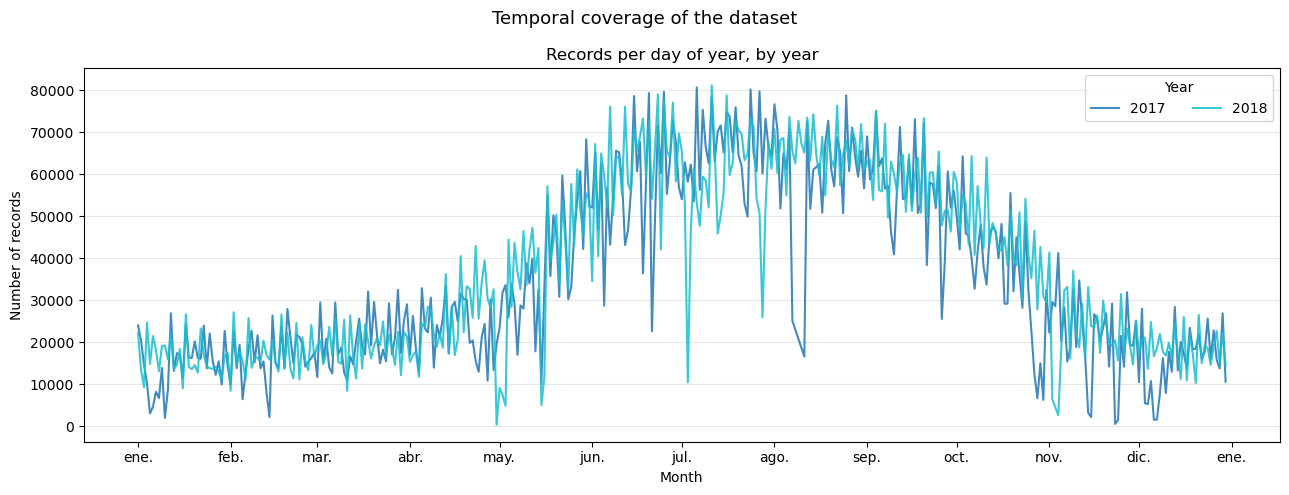

In [8]:
temporal = (
    df.groupby(['year', 'day_of_year'])
      .size()
      .reset_index(name='count')
)

years  = sorted(temporal['year'].unique().astype(int))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(years)))

# Map each day_of_year to a date in a fixed reference year so the
# x-axis can display month names while all series share the same range.

fig, ax = plt.subplots(figsize=(13, 5))

for year, color in zip(years, colors):
    subset = temporal[temporal['year'] == year].sort_values('day_of_year')
    dates = pd.to_datetime(
        subset['day_of_year'].astype(int).apply(lambda d: f'{REF_YEAR}-{d:03d}'),
        format='%Y-%j',
    )
    ax.plot(dates, subset['count'], label=str(year),
            color=color, alpha=0.85, linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlabel('Month')
ax.set_ylabel('Number of records')
ax.set_title('Records per day of year, by year')
ax.legend(title='Year', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal coverage of the dataset', fontsize=13)
plt.tight_layout()
plt.show()

Suprisingly, there is considerably more data in the months from May to November.

### Geographical distribution

We then inspect the spatial coverage: how many observations each grid point (latitude, longitude) has accumulated across all days. A uniform spatial coverage is desirable to avoid geographical biases in the model; any systematically under-sampled region should be noted.

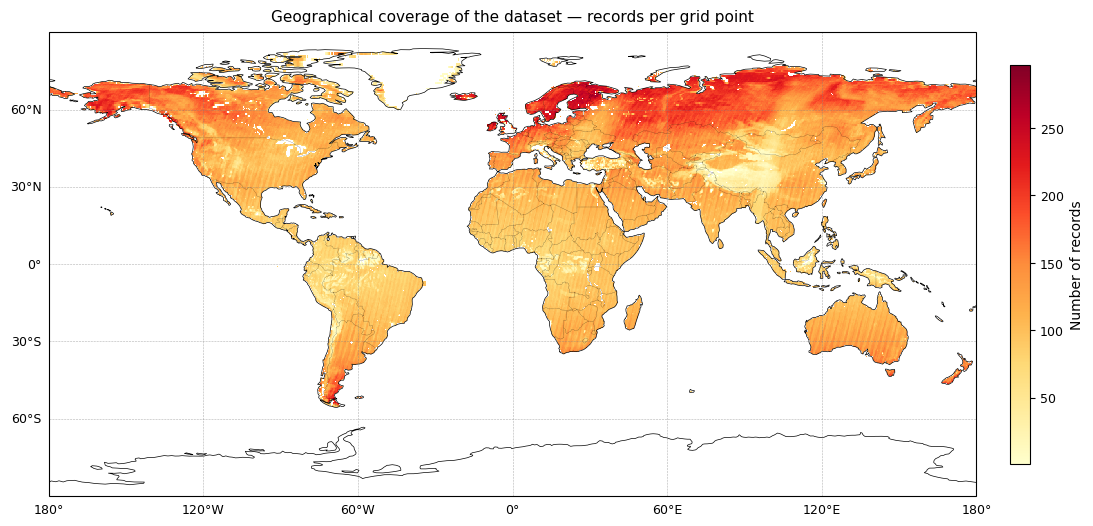

: 

In [ ]:
# ── 1. Compute records per location ─────────────────────────────────────────
records_per_loc = (
    df.groupby(['latitude_grid', 'longitude_grid'])
    .size()
    .reset_index(name='count')
)

# ── 2. Remap longitudes [0, 360] → [−180, 180] ──────────────────────────────
records_per_loc['longitude_grid'] = (
    (records_per_loc['longitude_grid'] + 180) % 360
) - 180

# ── 3. Pivot to 2-D grid ─────────────────────────────────────────────────────
pivot_count = records_per_loc.pivot(
    index='latitude_grid',
    columns='longitude_grid',
    values='count'
)

lats = pivot_count.index.values
lons = pivot_count.columns.values
data = pivot_count.values

# ── 4. Plot with Cartopy ─────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    lons, lats, data,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Number of records", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Geographical coverage of the dataset — records per grid point",
             fontsize=11, pad=8)

plt.tight_layout()
plt.show()

cnt = records_per_loc['count']

The closer the point is to a pole, the more data we have of it. This may be related to the measuring method.

## Univariate statistical analysis

We analyze each variable's distribution to understand data characteristics before modeling.

### Surface water fraction

`fwns` is the target variable (fractional surface water coverage). We examine its distribution, the proportion of zero values (dry-land observations), and evaluate common transformations to reduce its strong zero-skew.

Total zeros: 8,683,427  (32.79% of all observations)


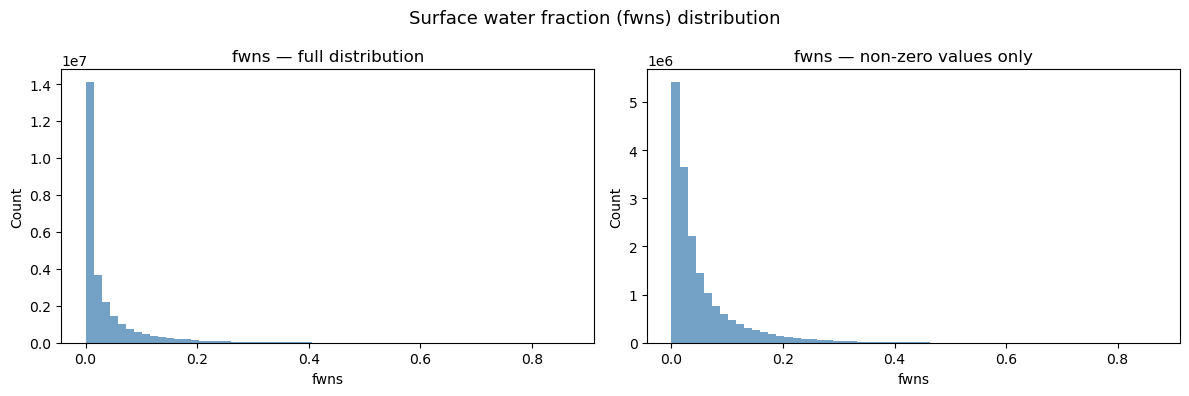

: 

In [ ]:
# Zero value analysis
n_zeros = (df['fwns'] == 0).sum()
pct_zeros = n_zeros / len(df) * 100
print(f"Total zeros: {n_zeros:,}  ({pct_zeros:.2f}% of all observations)")

# Distribution plot — full and non-zero side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fwns'], bins=60, color='steelblue', alpha=0.75)
axes[0].set_title('fwns — full distribution')
axes[0].set_xlabel('fwns')
axes[0].set_ylabel('Count')

x_pos = df['fwns'][df['fwns'] > 0]
axes[1].hist(x_pos, bins=60, color='steelblue', alpha=0.75)
axes[1].set_title('fwns — non-zero values only')
axes[1].set_xlabel('fwns')
axes[1].set_ylabel('Count')

plt.suptitle('Surface water fraction (fwns) distribution', fontsize=13)
plt.tight_layout()
plt.show()

`fwns` is clearly skewed towards zero. Let's compare different transformations to see which one leads to a more normal distribution.

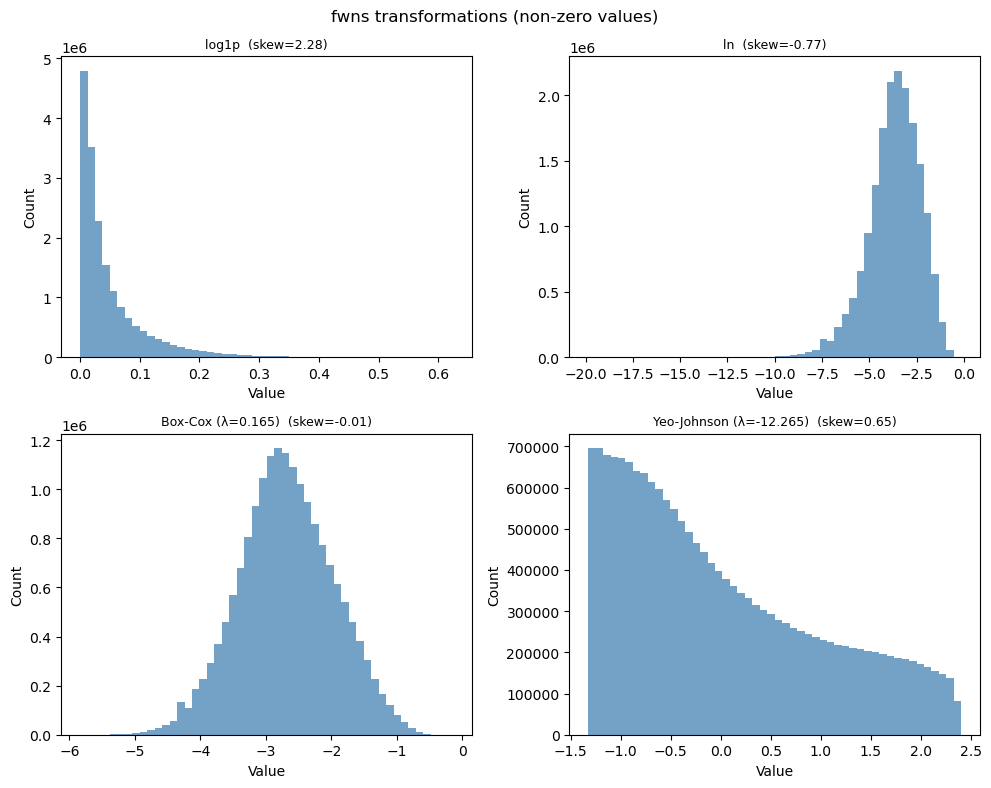

: 

In [ ]:
x_pos = df['fwns'][df['fwns'] > 0]

x_log1p  = np.log1p(x_pos)
x_ln     = x_pos.apply(np.log)
x_boxcox, lam_bc = stats.boxcox(x_pos)
pt = PowerTransformer(method='yeo-johnson')
x_yj = pt.fit_transform(x_pos.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

plots = [
    (axes[0], x_log1p,  f'log1p  (skew={stats.skew(x_log1p):.2f})'),
    (axes[1], x_ln,     f'ln  (skew={stats.skew(x_ln):.2f})'),
    (axes[2], x_boxcox, f'Box-Cox (λ={lam_bc:.3f})  (skew={stats.skew(x_boxcox):.2f})'),
    (axes[3], x_yj,     f'Yeo-Johnson (λ={pt.lambdas_[0]:.3f})  (skew={stats.skew(x_yj):.2f})'),
]
for ax, data, title in plots:
    ax.hist(data, bins=50, color='steelblue', alpha=0.75)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

fig.suptitle('fwns transformations (non-zero values)', fontsize=12)
plt.tight_layout()
plt.show()

Box-Cox is the clear winner, and may serve as a better target variable than the original.

### Brightness temperatures

`tbtoa` (top-of-atmosphere), `tran` (atmospheric transmittance), `tbdw` (downwelling),
and `tbup` (upwelling) are each available at 19 GHz and 37 GHz, in both V and H
polarizations. Each variable occupies one row; all four channels are overlaid with
transparency and distinct colors to facilitate direct comparison.

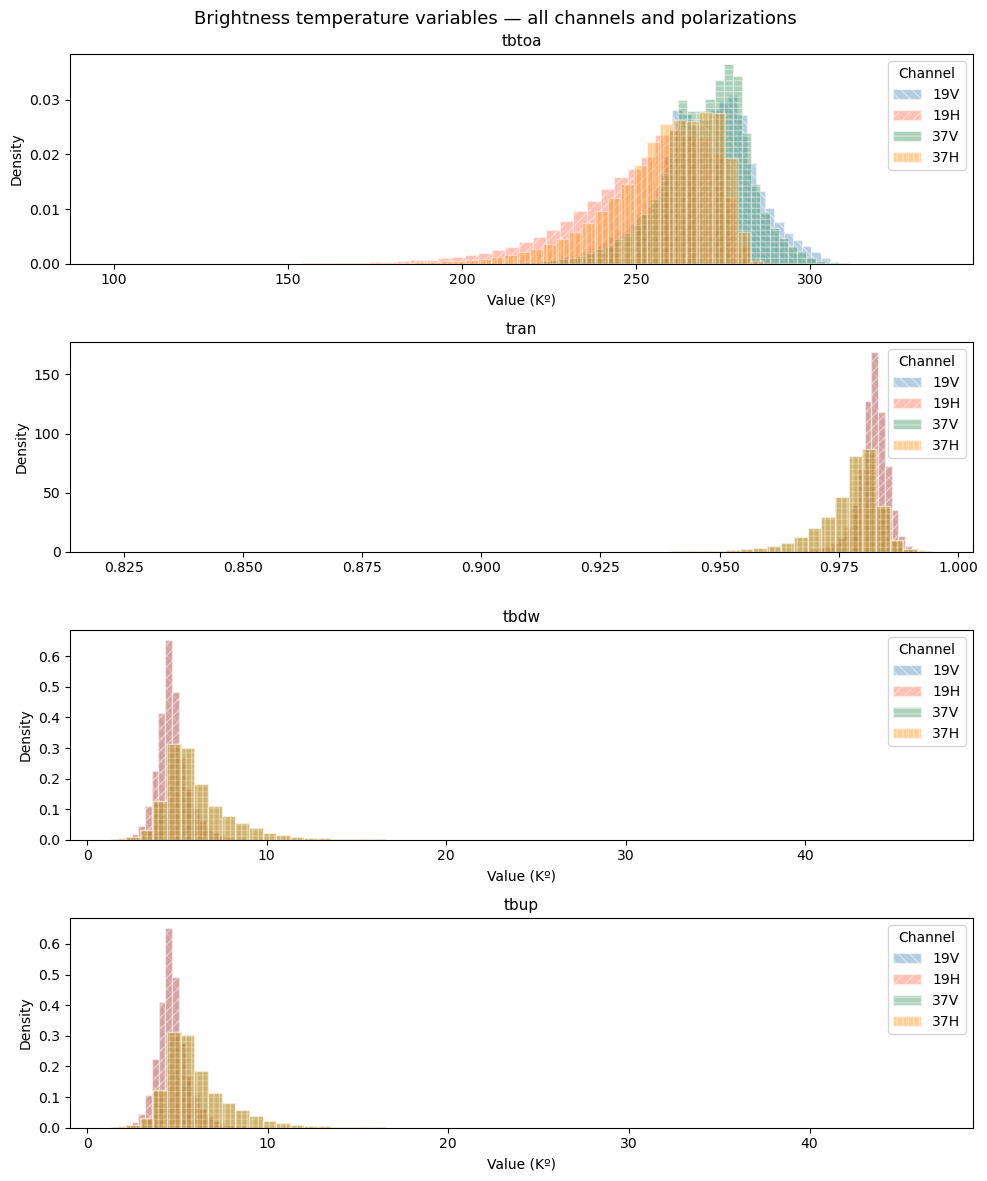

In [6]:
bt_vars = {
    'tbtoa': ['tbtoa19V', 'tbtoa19H', 'tbtoa37V', 'tbtoa37H'],
    'tran':  ['tran19V',  'tran19H',  'tran37V',  'tran37H'],
    'tbdw':  ['tbdw19V',  'tbdw19H',  'tbdw37V',  'tbdw37H'],
    'tbup':  ['tbup19V',  'tbup19H',  'tbup37V',  'tbup37H'],
}
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']
hatches = ['\\\\\\', '///', '---', '|||']
labels  = ['19V', '19H', '37V', '37H']

fig, axes = plt.subplots(4, 1, figsize=(10, 12))

for ax, (var_name, cols) in zip(axes, bt_vars.items()):
    for col, color, hatch, label in zip(cols, colors, hatches, labels):
        ax.hist(df[col].dropna(), bins=60, alpha=0.4, color=color,
                hatch=hatch, edgecolor='white', label=label, density=True)
    ax.set_title(var_name, fontsize=11)
    if var_name != 'tran':
        ax.set_xlabel('Value (Kº)')
    ax.set_ylabel('Density')
    ax.legend(title='Channel')

plt.suptitle('Brightness temperature variables — all channels and polarizations',
             fontsize=13)
plt.tight_layout()
plt.show()

As we can see, the variables tran, tbdw and tbup have many shortcomings. Firstly, the frequencies ditributions are the same within a polarization. Secondly, all three variables follow the exact same distribution, with only tran seemingly being flipped and scaled. We'll see if this is due to the visualization or if there is clear data repetition at play in the next section.

It must be noted that tbtoa presents no such problems, with expected distributions.

### Auxiliary variables

The remaining predictors — surface temperature (`surtep_ERA5`), volumetric soil
moisture (`vsm`), vegetation optical depth (`VOD`), minimum temperature (`Tmn`),
precipitable water vapor (`PWV`), and vapor pressure deficit (`VPD`) — are shown
individually.

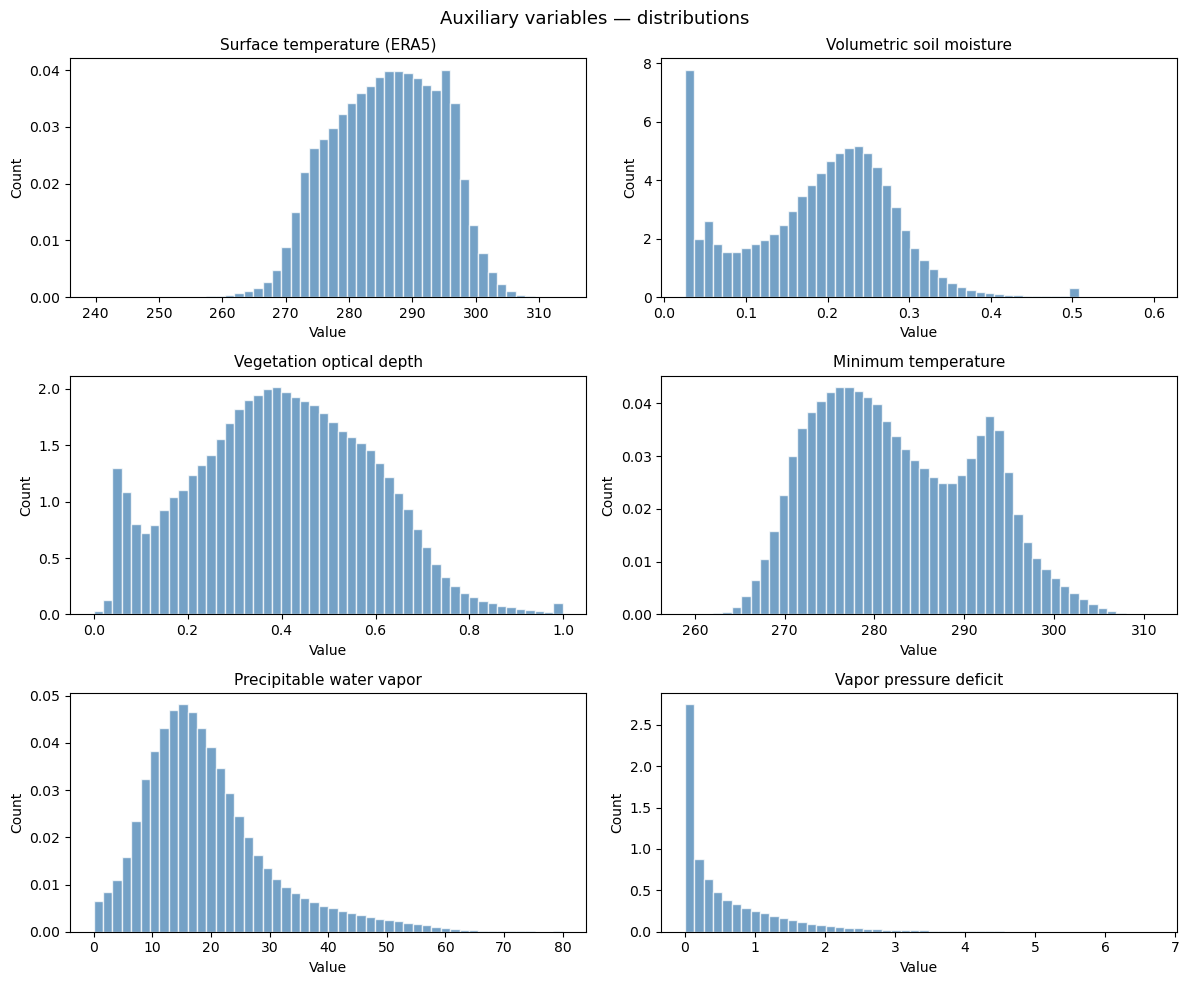

In [7]:
aux_vars = ['surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD']
aux_labels = {
    'surtep_ERA5': 'Surface temperature (ERA5)',
    'vsm':         'Volumetric soil moisture',
    'VOD':         'Vegetation optical depth',
    'Tmn':         'Minimum temperature',
    'PWV':         'Precipitable water vapor',
    'VPD':         'Vapor pressure deficit',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, aux_vars):
    ax.hist(df[var].dropna(), bins=50, color='steelblue', alpha=0.75, edgecolor='white', density=True)
    ax.set_title(aux_labels[var], fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Auxiliary variables — distributions', fontsize=13)
plt.tight_layout()
plt.show()

The different variables present mostly usual distributions.

## Multivariate analysis

With as many as 52 variables in a dataset, it is imperative that we study their relationships.

### Brightness temperature correlation

As we've seen before, the non tbtoa brightness temperature variables presented some repetition. Let's study these relations thoroughly.

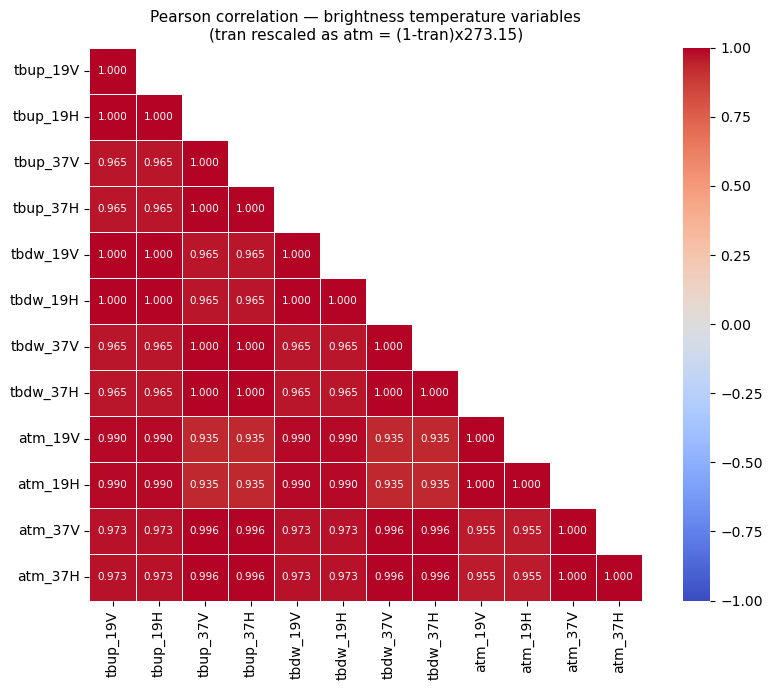

,Comparison type,Variable A,Variable B,r,R²,MAE,RMSE
0,Polarization (V vs H),tbup_19V,tbup_19H,1.0000,1.0000,0.0000,0.0000
1,Polarization (V vs H),tbup_37V,tbup_37H,1.0000,1.0000,0.0000,0.0000
2,Polarization (V vs H),tbdw_19V,tbdw_19H,1.0000,1.0000,0.0000,0.0000
3,Polarization (V vs H),tbdw_37V,tbdw_37H,1.0000,1.0000,0.0000,0.0000
4,Polarization (V vs H),atm_19V,atm_19H,1.0000,1.0000,0.0000,0.0000
5,Polarization (V vs H),atm_37V,atm_37H,1.0000,1.0000,0.0000,0.0000
6,Frequency (19 vs 37 GHz),tbup_19V,tbup_37V,0.9651,0.9315,1.3529,1.7080
7,Frequency (19 vs 37 GHz),tbup_19H,tbup_37H,0.9651,0.9315,1.3529,1.7080
8,Frequency (19 vs 37 GHz),tbdw_19V,tbdw_37V,0.9651,0.9315,1.3547,1.7105
9,Frequency (19 vs 37 GHz),tbdw_19H,tbdw_37H,0.9651,0.9315,1.3547,1.7105


In [9]:
# Rescale tran so it is comparable to tbup / tbdw (Kelvin range)
# (1 - tran) is atmospheric opacity; *100 puts it on a roughly similar scale
bt_cmp = pd.DataFrame({
    'tbup_19V': df['tbup19V'], 'tbup_19H': df['tbup19H'],
    'tbup_37V': df['tbup37V'], 'tbup_37H': df['tbup37H'],
    'tbdw_19V': df['tbdw19V'], 'tbdw_19H': df['tbdw19H'],
    'tbdw_37V': df['tbdw37V'], 'tbdw_37H': df['tbdw37H'],
    'atm_19V':  (1 - df['tran19V']) * 273.15,
    'atm_19H':  (1 - df['tran19H']) * 273.15,
    'atm_37V':  (1 - df['tran37V']) * 273.15,
    'atm_37H':  (1 - df['tran37H']) * 273.15,
}).dropna()

# ── 1. Correlation heatmap (lower triangle) ──────────────────────────────────
corr = bt_cmp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, mask=mask, annot_kws={'size': 7.5}, ax=ax,
)
ax.set_title(
    'Pearson correlation — brightness temperature variables\n'
    '(tran rescaled as atm = (1-tran)x273.15)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── 2. Structured pair-comparison table ──────────────────────────────────────
def pair_stats(col_a, col_b):
    a, b = bt_cmp[col_a].values, bt_cmp[col_b].values
    r, _ = stats.pearsonr(a, b)
    mae  = np.mean(np.abs(a - b))
    rmse = np.sqrt(np.mean((a - b) ** 2))
    return r, r ** 2, mae, rmse

pair_groups = {
    # Same variable & frequency, different polarization (V vs H)
    'Polarization (V vs H)': [
        ('tbup_19V', 'tbup_19H'), ('tbup_37V', 'tbup_37H'),
        ('tbdw_19V', 'tbdw_19H'), ('tbdw_37V', 'tbdw_37H'),
        ('atm_19V',  'atm_19H'),  ('atm_37V',  'atm_37H'),
    ],
    # Same variable & polarization, different frequency (19 vs 37 GHz)
    'Frequency (19 vs 37 GHz)': [
        ('tbup_19V', 'tbup_37V'), ('tbup_19H', 'tbup_37H'),
        ('tbdw_19V', 'tbdw_37V'), ('tbdw_19H', 'tbdw_37H'),
        ('atm_19V',  'atm_37V'),  ('atm_19H',  'atm_37H'),
    ],
    # Same frequency & polarization, different physical variable (tbup vs tbdw vs atm)
    'Variable (tbup / tbdw / atm)': [
        ('tbup_19V', 'tbdw_19V'), ('tbup_19V', 'atm_19V'), ('tbdw_19V', 'atm_19V'),
        ('tbup_19H', 'tbdw_19H'), ('tbup_19H', 'atm_19H'), ('tbdw_19H', 'atm_19H'),
        ('tbup_37V', 'tbdw_37V'), ('tbup_37V', 'atm_37V'), ('tbdw_37V', 'atm_37V'),
        ('tbup_37H', 'tbdw_37H'), ('tbup_37H', 'atm_37H'), ('tbdw_37H', 'atm_37H'),
    ],
}

rows = []
for group, pairs in pair_groups.items():
    for col_a, col_b in pairs:
        r, r2, mae, rmse = pair_stats(col_a, col_b)
        rows.append({
            'Comparison type': group,
            'Variable A': col_a, 'Variable B': col_b,
            'r': round(r, 4), 'R²': round(r2, 4),
            'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
        })

tbl = pd.DataFrame(rows)

# Colour-code R² to make near-duplicates stand out
tbl.style \
    .background_gradient(subset=['r', 'R²'], cmap='RdYlGn', vmin=0, vmax=1) \
    .background_gradient(subset=['MAE', 'RMSE'], cmap='RdYlGn_r') \
    .format({'r': '{:.4f}', 'R²': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}'})

Some important discoveries that can be derived:
1. Polarization makes no discernable difference in the data. As such, we can limit the polarizations to just one.
2. The difference between frequencies is significative.
3. `tbup` and `tbdw` are extremely similar. `atm` is the most distinct, although that may very well be because of the inexact reescaling. It can be assumed, with a degree of error, that all three variables represent the same values.

### Correlation matrix

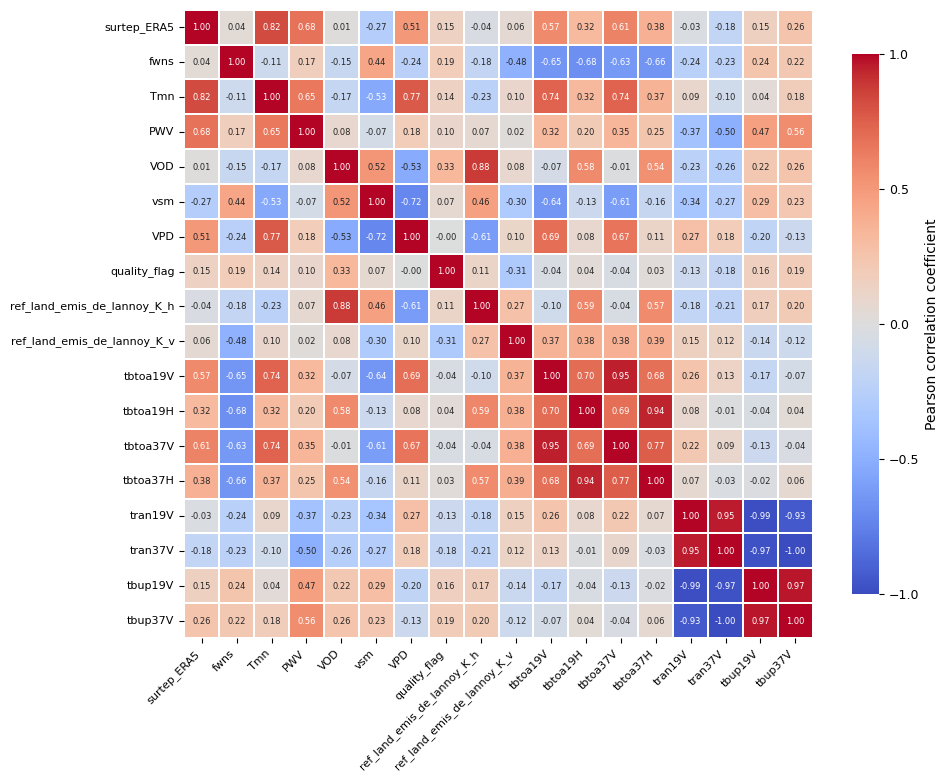

: 

In [ ]:
corr = df.drop(columns=[
    'latitude_grid', 'longitude_grid', 'tran19H', 'tran37H', 'tbup19H', 'tbup37H',
    'tbdw19V', 'tbdw37V', 'tbdw19H', 'tbdw37H', 'clase', 'porcentaje clase',
    'day_of_year', 'year', 'doy_sin', 'doy_cos', 'lon_sin', 'lon_cos',
    'tbboa_1st_order19H', 'tbboa_1st_order37H', 'tbboa_1st_order19V', 'tbboa_1st_order37V',
    'tbboa_de_lannoy19H', 'tbboa_de_lannoy37H', 'tbboa_de_lannoy19V', 'tbboa_de_lannoy37V',
    'emiss19H_de_lannoy', 'emiss37H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37V_de_lannoy',
    'denominator', 'term_1', 'term_2', 'fwns_calculated'
]).corr(numeric_only=True)

n = len(corr.columns)
cell_size = 0.55  # inches per cell — increase for larger numbers
fig_size = n * cell_size

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "shrink": 0.6,
        "label": "Pearson correlation coefficient",
        "orientation": "vertical",
    },
)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, rotation=0, fontsize=8)

# Style the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Pearson correlation coefficient", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

plt.tight_layout()
plt.show()

We can see the expected strong correlation between the different frequencies and polarizations of ``tbtoa``, and the ``tran`` and ``tbup`` values.

A big negative correlation can also be observed between ``tbtoa`` and ``fwns``, a promising result.

Some other notable correlations are ``ref_land_emis_de_lannoy_K_h`` with ``VOD``, or ``Tmn`` with ``tbtoa`` and ``VPD``.

## Machine learning oriented analysis

Let's check specific points in the structure of the dataset that could tell us better ways of training models.

### Scaling needs

In [17]:
df.max() - df.min()

latitude_grid                  138.000000
longitude_grid                 359.750000
surtep_ERA5                     74.037567
fwns                             0.868315
Tmn                             52.225739
PWV                             80.000000
VOD                              0.998577
vsm                              0.575000
VPD                              6.695256
quality_flag                   192.000000
ref_land_emis_de_lannoy_K_h      0.184196
ref_land_emis_de_lannoy_K_v      0.111272
tbtoa19V                       159.584991
tbtoa19H                       234.137512
tbtoa37V                       157.980011
tbtoa37H                       223.125000
tran19V                          0.084637
tran19H                          0.084637
tran37V                          0.171902
tran37H                          0.171902
tbdw19V                         22.507769
tbdw19H                         22.507769
tbdw37V                         45.667213
tbdw37H                         45

We can see that even though `fwns` has really small consistent values, other ones like ``surtep_ERA5`` or tbtoa have extremely large values. We may need to scale this features down or outright remove them to improve our training.

### Dimensionality study

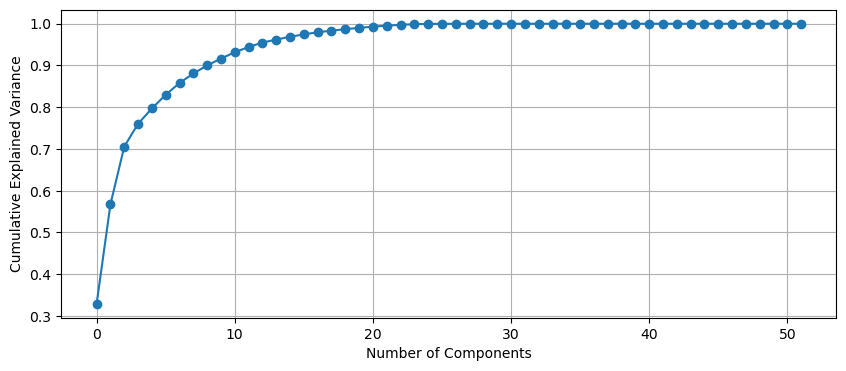

In [8]:
numeric_df = df.select_dtypes(include='number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10,4))
plt.plot(cumulative, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

Most of the dataset can be explained with around 20 variables, pointing to a bloated number variables.

## Spatial and temporal structure

Each unit of data in our project corresponds to a single point in time and space. If we understand the interaction between our data and their spatial and temporal context, we will be able to better manage it and understand how it affects our final results.

### Temporal study

Point by point, let's study `fwns` stadistics in time. This will help us understand `fwns` better.

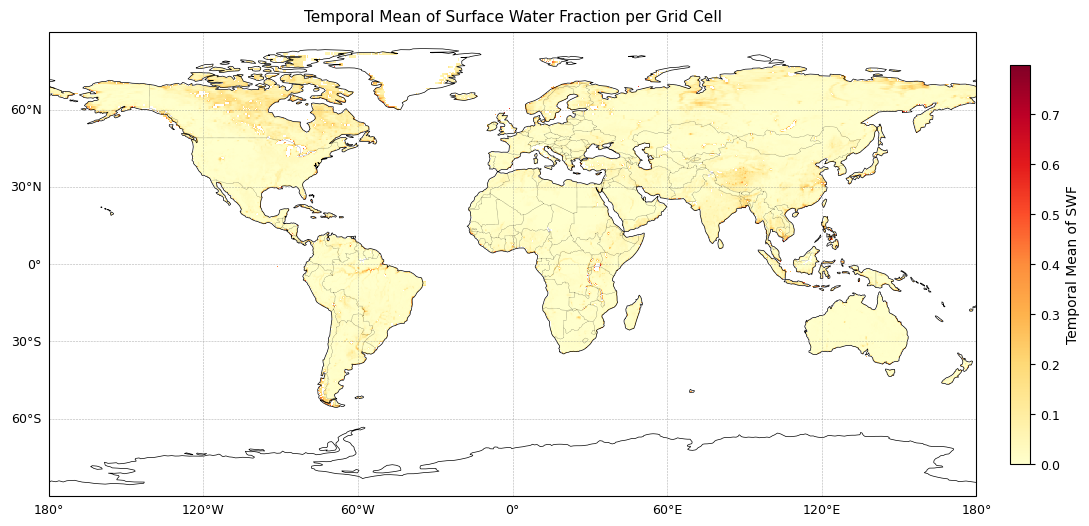

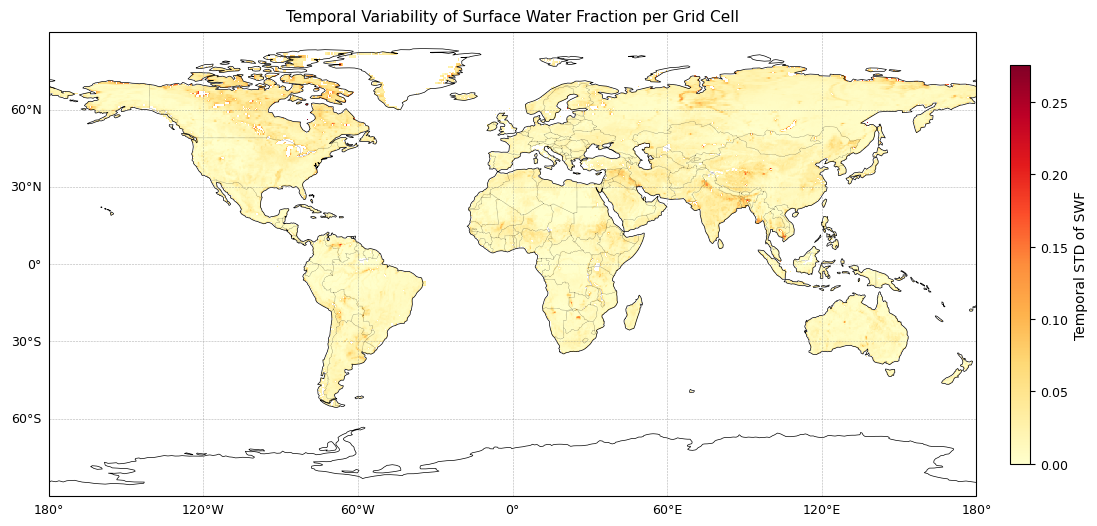

In [32]:
# ── 1. Compute temporal stats ────────────────────────────────────────────────
temporal_stats = (
    df.groupby(["latitude_grid", "longitude_grid"])["fwns"]
    .agg(["mean", "std", "var", "count"])
    .reset_index()
)
temporal_stats["cv"] = temporal_stats["std"] / temporal_stats["mean"]

# ── 2. Remap longitudes from [0, 360] → [−180, 180] ─────────────────────────
temporal_stats["longitude_grid"] = (
    (temporal_stats["longitude_grid"] + 180) % 360
) - 180

# ── 3. Pivot to 2-D grid (rows = lat, cols = lon) ───────────────────────────
pivot_mean = temporal_stats.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="mean"
)

lats_mean = pivot_mean.index.values       # 1-D array of latitudes
lons_mean = pivot_mean.columns.values     # 1-D array of longitudes (now −180..180)
data_mean = pivot_mean.values             # 2-D array (NaN where no data)

pivot_std = temporal_stats.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="std"
)

lats_std = pivot_std.index.values       # 1-D array of latitudes
lons_std = pivot_std.columns.values     # 1-D array of longitudes (now −180..180)
data_std = pivot_std.values             # 2-D array (NaN where no data)

# ── 4. Plot with Cartopy ─────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    lons_mean, lats_mean, data_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    shading="auto",
)

# Coastlines and borders
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Temporal Mean of SWF", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Temporal Mean of Surface Water Fraction per Grid Cell",
             fontsize=11, pad=8)

plt.tight_layout()

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    lons_std, lats_std, data_std,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    shading="auto",
)

# Coastlines and borders
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Temporal STD of SWF", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Temporal Variability of Surface Water Fraction per Grid Cell",
             fontsize=11, pad=8)

plt.tight_layout()
plt.show()

### Spatial variability

Day by day, let's study `fwns` stadistics globaly. This will help us understand `fwns` better.

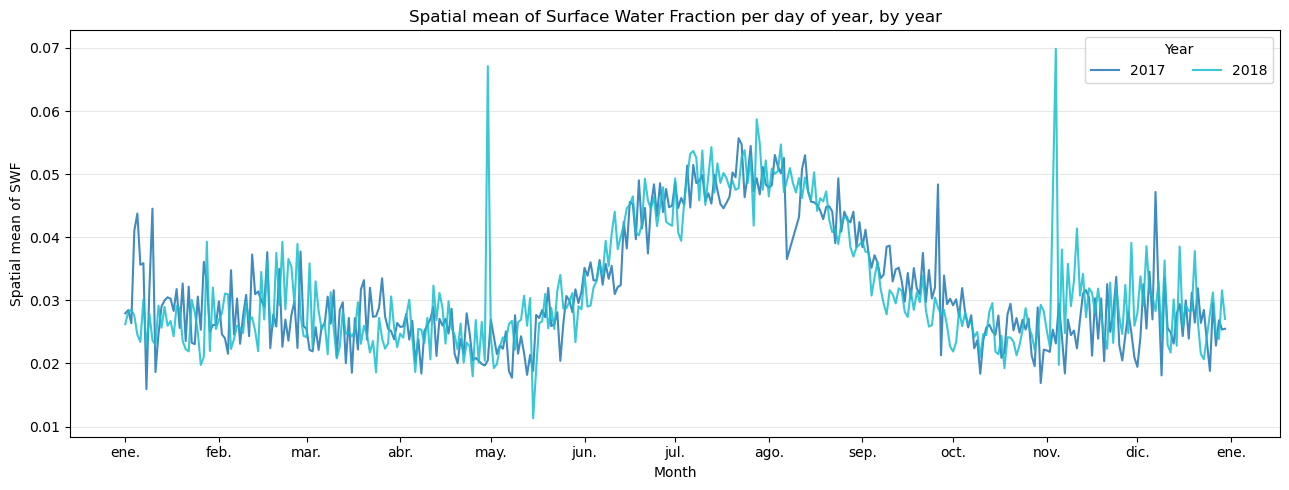

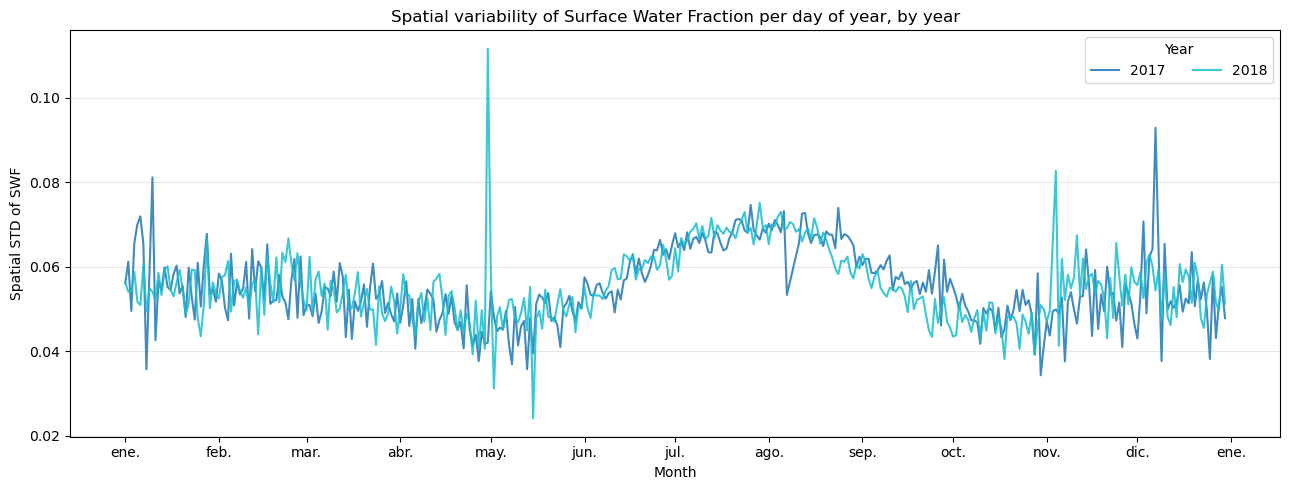

In [ ]:
# ── 1. Compute spatial stats grouped by year + day_of_year ──────────────────
spatial_stats = (
    df.groupby(['year', 'day_of_year'])['fwns']
    .agg(['mean', 'std'])
    .reset_index()
)

years  = sorted(spatial_stats['year'].unique().astype(int))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(years)))

# ── 2. Helper to avoid code duplication ─────────────────────────────────────
def plot_spatial_stat(metric, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(13, 5))
    for year, color in zip(years, colors):
        subset = spatial_stats[spatial_stats['year'] == year].sort_values('day_of_year')
        dates  = pd.to_datetime(
            subset['day_of_year'].astype(int).apply(lambda d: f'{REF_YEAR}-{d:03d}'),
            format='%Y-%j',
        )
        ax.plot(dates, subset[metric], label=str(year),
                color=color, alpha=0.85, linewidth=1.5)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Year', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── 3. Mean plot ─────────────────────────────────────────────────────────────
plot_spatial_stat(
    metric   = 'mean',
    ylabel   = 'Spatial mean of SWF',
    title    = 'Spatial mean of Surface Water Fraction per day of year, by year',
    filename = 'swf_spatial_mean_time.pdf',
)

# ── 4. STD plot ──────────────────────────────────────────────────────────────
plot_spatial_stat(
    metric   = 'std',
    ylabel   = 'Spatial STD of SWF',
    title    = 'Spatial variability of Surface Water Fraction per day of year, by year',
    filename = 'swf_spatial_std_time.pdf',
)